# ACTOR CRITIC MODEL FOR 3 SPHERES

In [2]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

In [3]:
States = { 1:(10,10) , 2:(6,10) , 3:(6,6) ,4:(10,6) }
Actions = { 1:(4,0) , 2:(-4,0) , 3:(0,4) , 4:(0,-4)}
valid_actions = {1:[2,4] , 2:[1,4] , 3:[1,3] , 4:[2,3]}
transition = {1 : {1:None ,2:2 ,3:None ,4:4},
              2 : {1:1 ,2:None ,3:None ,4:3},
              3 : {1:4 ,2:None ,3:2 ,4:None},
              4 : {1:None ,2:3 ,3:1 ,4:None}}
rewards = {1 : {2:-1.37 ,4:1.33},
           2 : {1:1.37 ,4:1.46},
           3 : {1:1.41 ,3:-1.46},
           4 : {2:-1.41 ,3:-1.33}}
rewards_ss = {1 : {2:-1.37 ,4:1.33},
              2 : {1:1.37 ,3:1.46},
              3 : {4:1.41 ,2:-1.46},
              4 : {3:-1.41 ,1:-1.33}}

In [4]:
states_list = list(States.keys())
actions_list = list(Actions.keys())
num_states = len(states_list)
num_actions = len(actions_list)

In [5]:
gamma = 0.99
lr = 0.01

# NN - Architecture :

I am using two separate neural networks for actor and critic .

          -For Actor the input is one hot encoded state vector and has 16 units in its hidden layer .The output is probability distribution over all the allowed actions.
          
          -For Critic the input is state vector(one hot encoded) and has same number (16) units of neuron in      hidden layer . The output is a scalar value 

In [6]:
def one_hot_state(state_num):
    return tf.one_hot(state_num - 1,depth = num_states)

class Actor(tf.keras.Model):
    def __init__(self):
        super(Actor,self).__init__()
        self.d = tf.keras.layers.Dense(16,activation = 'relu')
        self.out = tf.keras.layers.Dense(num_states)
    
    def call(self,state_vec,mask):
        x = self.d(state_vec)
        out = self.out(x)
        neg_inf = tf.ones_like(out) * (-1e9)
        masked = tf.where(mask,out,neg_inf)
        return tf.nn.softmax(masked)

class Critic(tf.keras.Model):
    def __init__(self):
        super(Critic,self).__init__()
        self.d = tf.keras.layers.Dense(16,activation = 'relu')
        self.out = tf.keras.layers.Dense(1)
    
    def call(self,state):
        out = self.d(state)
        out = self.out(out)
        return out

In [8]:
def sample_env(state,action):
    next_state = transition[state][action]
    reward = rewards[state][action]
    return next_state,reward

actor = Actor()
critic = Critic()
actor_optimizer = tf.keras.optimizers.Adam(lr)
critic_optimizer = tf.keras.optimizers.Adam(lr)

In [9]:
def train_step(state):
    state_vec = one_hot_state(state)
    allowed = valid_actions[state]
    mask = np.zeros(num_actions , dtype = bool)
    for a in allowed:
        mask[a-1] = True
        
    with tf.GradientTape(persistent = True) as tape:
        probs = actor(tf.expand_dims(state_vec,0),tf.convert_to_tensor([mask]))
        action_dict = tf.squeeze(probs)
        action = np.random.choice(actions_list,p = action_dict.numpy())
        
        next_state,reward = sample_env(state,action)
        
        next_state_vec = one_hot_state(next_state)
        value = tf.squeeze(critic(tf.expand_dims(state_vec , 0)))
        next_value = tf.squeeze(critic(tf.expand_dims(next_state_vec,0)))
        
        target = reward + gamma * next_value
        advantage = target - value
        
        log_prob = tf.math.log(action_dict[action - 1] + 1e-9)
        actor_loss = -log_prob * advantage
        critic_loss = tf.square(advantage)
    
    actor_grads = tape.gradient(actor_loss,actor.trainable_variables)
    critic_grads = tape.gradient(critic_loss,critic.trainable_variables)
    
    actor_optimizer.apply_gradients(zip(actor_grads ,actor.trainable_variables))
    critic_optimizer.apply_gradients(zip(critic_grads ,critic.trainable_variables))
    
    
    return next_state

In [10]:
def train(episodes = 1000):
    reward_hist = []
    i = 0
    steps = 10
    reward = 0
    for ep in range(episodes):
        state = s = random.choice(states_list)
        for _ in range(steps):
            state = train_step(state)
            reward += rewards_ss[s][state]
            s = state
        reward_hist.append(reward)   
        i += 1
        if i % 50 == 0:
            print("Episode : ",i)
    
    return reward_hist,episodes

In [11]:
def select_action(state):
    state_vec = one_hot_state(state)
    allowed = valid_actions[state]
    mask = np.zeros(num_actions,dtype = bool)
    for a in allowed:
        mask[a-1] = True
    probs = actor(tf.expand_dims(state_vec, 0), tf.convert_to_tensor([mask]))
    return tf.argmax(probs[0]).numpy() + 1

In [12]:
print("Policy_before_training")
for s in states_list:
    print(f"At State {s} : Best action - {select_action(s)} --> Corresponding next state {transition[s][select_action(s)]}")

Policy_before_training
At State 1 : Best action - 4 --> Corresponding next state 4
At State 2 : Best action - 4 --> Corresponding next state 3
At State 3 : Best action - 3 --> Corresponding next state 2
At State 4 : Best action - 2 --> Corresponding next state 3


In [13]:
a , b = train()
print("---------"*4)
print("Optimal_Policy_after_training")
for s in states_list:
    print(f"At State {s} : Best action - {select_action(s)} --> Corresponding next state {transition[s][select_action(s)]}")

Episode :  50
Episode :  100
Episode :  150
Episode :  200
Episode :  250
Episode :  300
Episode :  350
Episode :  400
Episode :  450
Episode :  500
Episode :  550
Episode :  600
Episode :  650
Episode :  700
Episode :  750
Episode :  800
Episode :  850
Episode :  900
Episode :  950
Episode :  1000
------------------------------------
Optimal_Policy_after_training
At State 1 : Best action - 2 --> Corresponding next state 2
At State 2 : Best action - 4 --> Corresponding next state 3
At State 3 : Best action - 1 --> Corresponding next state 4
At State 4 : Best action - 3 --> Corresponding next state 1


In [14]:
print("Optimal_Policy_after_training")
for s in states_list:
    print(f"At State {s} : Best action : {select_action(s)} --> Corresponding next state {transition[s][select_action(s)]}")
    print(f"Current : {States[s]} ; Action : {Actions[select_action(s)]} ; Next state : {States[transition[s][select_action(s)]]}")
    print("------------")

Optimal_Policy_after_training
At State 1 : Best action : 2 --> Corresponding next state 2
Current : (10, 10) ; Action : (-4, 0) ; Next state : (6, 10)
------------
At State 2 : Best action : 4 --> Corresponding next state 3
Current : (6, 10) ; Action : (0, -4) ; Next state : (6, 6)
------------
At State 3 : Best action : 1 --> Corresponding next state 4
Current : (6, 6) ; Action : (4, 0) ; Next state : (10, 6)
------------
At State 4 : Best action : 3 --> Corresponding next state 1
Current : (10, 6) ; Action : (0, 4) ; Next state : (10, 10)
------------


Text(0, 0.5, 'Cumulative Displacement')

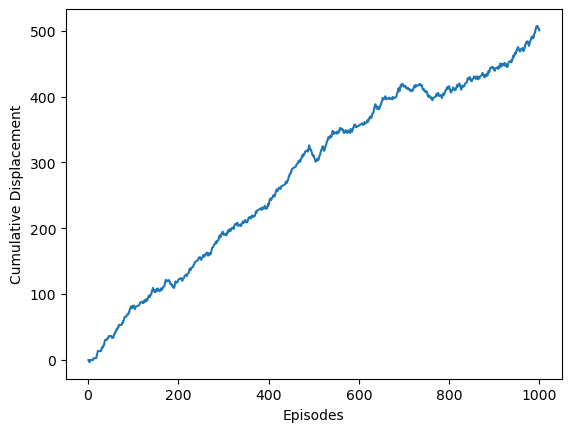

In [15]:
plt.plot(range(1,1001) , a)
plt.xlabel("Episodes")
plt.ylabel("Cumulative Displacement")

In [16]:
# Here in each episodes the swimmer takes 10 steps where each step updates the NN parameters .